# 🎵 Music Recommendation System — Neural Collaborative Filtering

> **Dataset**: Last.fm HetRec-2011 (~1,900 users, ~17,600 artists, ~92,000 interactions)  
> **Model**: Neural Collaborative Filtering (NCF) — He et al., 2017  
> **Framework**: PyTorch  

---


## 1 · Setup

In [ ]:
!pip install -q tqdm requests

In [ ]:
import os, sys, time, copy, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.manifold import TSNE

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Using device: {DEVICE}')
torch.manual_seed(42)
np.random.seed(42)

Using device: cuda


## 2 · Data Loading & Preprocessing

In [ ]:
import zipfile, requests

DATA_DIR = 'data'
os.makedirs(DATA_DIR, exist_ok=True)

DATASET_URL = 'https://files.grouplens.org/datasets/hetrec2011/hetrec2011-lastfm-2k.zip'

if not os.path.exists(os.path.join(DATA_DIR, 'user_artists.dat')):
    print('Downloading Last.fm dataset...')
    r = requests.get(DATASET_URL, stream=True)
    zip_path = os.path.join(DATA_DIR, 'lastfm.zip')
    with open(zip_path, 'wb') as f:
        for chunk in r.iter_content(8192):
            f.write(chunk)
    with zipfile.ZipFile(zip_path) as z:
        z.extractall(DATA_DIR)
    os.remove(zip_path)
    print('Done!')
else:
    print('Dataset already present.')

Done!


In [ ]:
# ── Loading raw files ────────────────────────────────────────────────────────
interactions = pd.read_csv(os.path.join(DATA_DIR, 'user_artists.dat'), sep='\t')
artists      = pd.read_csv(os.path.join(DATA_DIR, 'artists.dat'), sep='\t',
                           usecols=['id','name']).rename(columns={'id':'artistID'})
tags         = pd.read_csv(os.path.join(DATA_DIR, 'tags.dat'), sep='\t', encoding='latin-1')
user_tags    = pd.read_csv(os.path.join(DATA_DIR, 'user_taggedartists.dat'), sep='\t')

print('interactions:', interactions.shape)
print('artists:     ', artists.shape)
interactions.head()

interactions: (92834, 3)
artists:      (17632, 2)


,userID,artistID,weight
0,2,51,13883
1,2,52,11690
2,2,53,11351
3,2,54,10300
4,2,55,8983


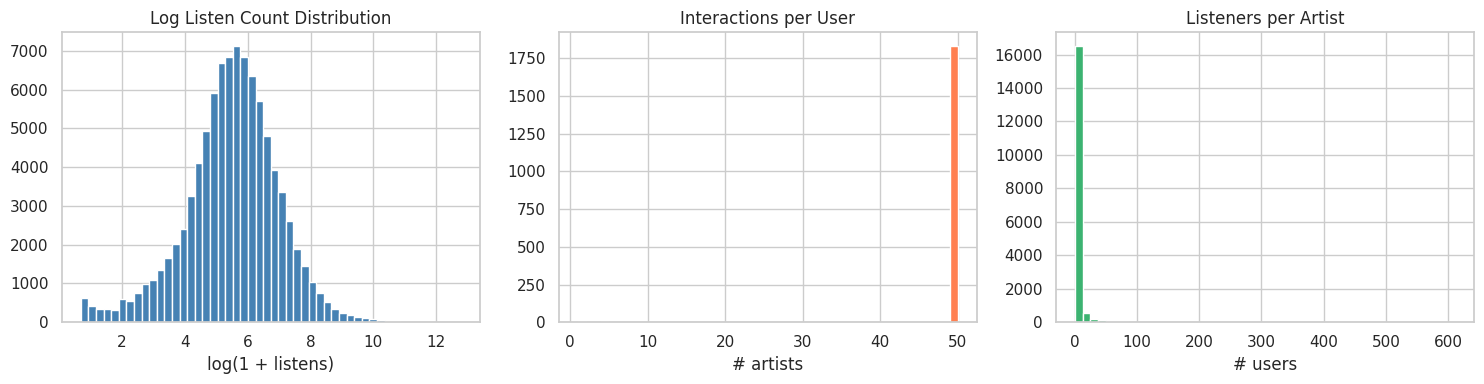

Sparsity: 99.7217%


In [ ]:
# ── EDA ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# 1. Distribution of listen counts (log scale)
axes[0].hist(np.log1p(interactions['weight']), bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Log Listen Count Distribution')
axes[0].set_xlabel('log(1 + listens)')

# 2. Interactions per user
user_counts = interactions.groupby('userID').size()
axes[1].hist(user_counts, bins=50, color='coral', edgecolor='white')
axes[1].set_title('Interactions per User')
axes[1].set_xlabel('# artists')

# 3. Interactions per artist
artist_counts = interactions.groupby('artistID').size()
axes[2].hist(artist_counts, bins=50, color='mediumseagreen', edgecolor='white')
axes[2].set_title('Listeners per Artist')
axes[2].set_xlabel('# users')

plt.tight_layout()
plt.show()
print(f'Sparsity: {1 - len(interactions) / (interactions.userID.nunique() * interactions.artistID.nunique()):.4%}')

In [ ]:
# ── Filtering & Re-indexing ──────────────────────────────────────────────────────
MIN_INTERACTIONS = 5

df = interactions.copy()
user_counts  = df['userID'].value_counts()
artist_counts = df['artistID'].value_counts()
df = df[
    df['userID'].isin(user_counts[user_counts >= MIN_INTERACTIONS].index) &
    df['artistID'].isin(artist_counts[artist_counts >= MIN_INTERACTIONS].index)
]

# contiguous integer indices for nn.Embedding
user2idx = {u: i for i, u in enumerate(df['userID'].unique())}
item2idx = {a: i for i, a in enumerate(df['artistID'].unique())}
idx2user = {v: k for k, v in user2idx.items()}
idx2item = {v: k for k, v in item2idx.items()}

df['user']  = df['userID'].map(user2idx)
df['item']  = df['artistID'].map(item2idx)
df['label'] = 1.0

NUM_USERS = len(user2idx)
NUM_ITEMS = len(item2idx)

print(f'Users:  {NUM_USERS:,}')
print(f'Items:  {NUM_ITEMS:,}')
print(f'Interactions: {len(df):,}')

Users:  1,874
Items:  2,828
Interactions: 71,411


In [ ]:
# ── Leave-one-out split ────────────────────────────────────────────────────
df = df[['user','item','label']].sample(frac=1, random_state=42)
df = df.groupby('user', group_keys=False).apply(
    lambda g: g.assign(_rank=range(len(g)))
)
test_df  = df[df['_rank'] == 0].drop(columns='_rank').reset_index(drop=True)
val_df   = df[df['_rank'] == 1].drop(columns='_rank').reset_index(drop=True)
train_df = df[df['_rank'] >= 2].drop(columns='_rank').reset_index(drop=True)

print(f'train: {len(train_df):,}  |  val: {len(val_df):,}  |  test: {len(test_df):,}')

train: 67,667  |  val: 1,870  |  test: 1,874


In [ ]:
# ── Negative Sampling (4 negatives per positive) ──────────────────────────
# For each positive (user, item) pair, we sample items the user has NOT listened to. These become 0-label training examples.

NUM_NEG_TRAIN = 4   # negatives per positive in training

rng = np.random.default_rng(42)
user_pos = train_df.groupby('user')['item'].apply(set).to_dict()

neg_rows = []
for _, row in tqdm(train_df.iterrows(), total=len(train_df), desc='Sampling negatives'):
    u = int(row['user'])
    seen = user_pos[u]
    count = 0
    while count < NUM_NEG_TRAIN:
        neg = rng.integers(0, NUM_ITEMS)
        if neg not in seen:
            neg_rows.append({'user': u, 'item': neg, 'label': 0.0})
            count += 1

train_with_neg = pd.concat(
    [train_df, pd.DataFrame(neg_rows)], ignore_index=True
).sample(frac=1, random_state=42).reset_index(drop=True)

print(f'Training samples (pos + neg): {len(train_with_neg):,}')

Sampling negatives:   0%|          | 0/67667 [00:00<?, ?it/s]

Training samples (pos + neg): 338,335


## 3 · Model Architecture

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
#  NCF — Neural Collaborative Filtering
#  He et al., 2017  →  https://arxiv.org/abs/1708.05031
# ═══════════════════════════════════════════════════════════════════════════

def build_mlp(input_dim, layer_sizes, dropout=0.2):
    layers, in_dim = [], input_dim
    for out_dim in layer_sizes:
        layers += [
            nn.Linear(in_dim, out_dim),
            nn.BatchNorm1d(out_dim),
            nn.ReLU(inplace=True),
            nn.Dropout(p=dropout)
        ]
        in_dim = out_dim
    return nn.Sequential(*layers), in_dim


class NCF(nn.Module):


    def __init__(self, num_users, num_items,
                 gmf_dim=32, mlp_dim=32,
                 mlp_layers=None, dropout=0.2):
        super().__init__()
        if mlp_layers is None:
            mlp_layers = [128, 64, 32]

        # ── GMF embeddings ──────────────────────────────────────────────────
        self.gmf_user = nn.Embedding(num_users, gmf_dim)
        self.gmf_item = nn.Embedding(num_items, gmf_dim)

        # ── MLP embeddings ──────────────────────────────────────────────────
        self.mlp_user = nn.Embedding(num_users, mlp_dim)
        self.mlp_item = nn.Embedding(num_items, mlp_dim)

        # ── MLP layers ──────────────────────────────────────────────────────
        self.mlp, mlp_out = build_mlp(mlp_dim * 2, mlp_layers, dropout)

        # ── Final prediction: fuse GMF + MLP ────────────────────────────────
        self.predict = nn.Linear(gmf_dim + mlp_out, 1, bias=False)

        self._init_weights()

    def _init_weights(self):
        for emb in [self.gmf_user, self.gmf_item, self.mlp_user, self.mlp_item]:
            nn.init.normal_(emb.weight, std=0.01)
        for m in self.mlp.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
        nn.init.kaiming_uniform_(self.predict.weight)

    def forward(self, user_ids, item_ids):
        # GMF path: element-wise product
        gmf_out = self.gmf_user(user_ids) * self.gmf_item(item_ids)

        # MLP path: concatenate → deep layers
        mlp_in  = torch.cat([self.mlp_user(user_ids),
                              self.mlp_item(item_ids)], dim=-1)
        mlp_out = self.mlp(mlp_in)

        # Fuse & predict
        return torch.sigmoid(self.predict(torch.cat([gmf_out, mlp_out], dim=-1))).squeeze(-1)


# ── Model summary ─────────────────────────────────────────────────────────
model = NCF(
    num_users  = NUM_USERS,
    num_items  = NUM_ITEMS,
    gmf_dim    = 32,
    mlp_dim    = 32,
    mlp_layers = [128, 64, 32],
    dropout    = 0.2,
).to(DEVICE)

total_params = sum(p.numel() for p in model.parameters())
print(model)
print(f'\nTotal parameters: {total_params:,}')

NCF(
  (gmf_user): Embedding(1874, 32)
  (gmf_item): Embedding(2828, 32)
  (mlp_user): Embedding(1874, 32)
  (mlp_item): Embedding(2828, 32)
  (mlp): Sequential(
    (0): Linear(in_features=64, out_features=128, bias=True)
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Dropout(p=0.2, inplace=False)
    (4): Linear(in_features=128, out_features=64, bias=True)
    (5): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU(inplace=True)
    (7): Dropout(p=0.2, inplace=False)
    (8): Linear(in_features=64, out_features=32, bias=True)
    (9): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU(inplace=True)
    (11): Dropout(p=0.2, inplace=False)
  )
  (predict): Linear(in_features=64, out_features=1, bias=False)
)

Total parameters: 320,096


## 4 · Training

In [ ]:
# ── PyTorch Datasets & DataLoaders ────────────────────────────────────────

class InteractionDataset(Dataset):
    def __init__(self, df):
        self.users  = torch.LongTensor(df['user'].values)
        self.items  = torch.LongTensor(df['item'].values)
        self.labels = torch.FloatTensor(df['label'].values)
    def __len__(self): return len(self.labels)
    def __getitem__(self, idx):
        return self.users[idx], self.items[idx], self.labels[idx]


class EvalDataset(Dataset):

    def __init__(self, pos_df, num_items, train_df, num_neg=99, seed=42):
        rng = np.random.default_rng(seed)
        user_seen = train_df.groupby('user')['item'].apply(set).to_dict()
        self.samples = []
        for _, row in pos_df.iterrows():
            u, pos = int(row['user']), int(row['item'])
            seen, negs = user_seen.get(u, set()), []
            while len(negs) < num_neg:
                neg = rng.integers(0, num_items)
                if neg not in seen and neg != pos:
                    negs.append(neg)
            self.samples.append((u, [pos] + negs))
    def __len__(self): return len(self.samples)
    def __getitem__(self, idx):
        u, items = self.samples[idx]
        return (torch.LongTensor([u] * len(items)),
                torch.LongTensor(items))


BATCH_SIZE = 512

train_dataset = InteractionDataset(train_with_neg)
train_loader  = DataLoader(train_dataset, batch_size=BATCH_SIZE,
                           shuffle=True, num_workers=0)

print('Building val eval dataset...')
val_eval_ds   = EvalDataset(val_df,  NUM_ITEMS, train_df)
print('Building test eval dataset...')
test_eval_ds  = EvalDataset(test_df, NUM_ITEMS, train_df)

print(f'Train batches: {len(train_loader)}')

Building val eval dataset...
Building test eval dataset...
Train batches: 661


In [ ]:
# ── Evaluation metrics ─────────────────────────────────────────────────────

def hit_rate_at_k(ranked_lists, k):
    """Fraction of users whose positive item is in top-K."""
    return sum(1 for rl in ranked_lists if 0 in rl[:k]) / len(ranked_lists)

def ndcg_at_k(ranked_lists, k):
    """Normalised Discounted Cumulative Gain at K."""
    scores = []
    for rl in ranked_lists:
        if 0 in rl[:k]:
            rank = rl.index(0) + 1
            scores.append(1.0 / np.log2(rank + 1))
        else:
            scores.append(0.0)
    return float(np.mean(scores))

@torch.no_grad()
def evaluate(model, eval_dataset, k_values=[10, 20], device=DEVICE):
    model.eval()
    ranked = []
    loader = DataLoader(eval_dataset, batch_size=1, shuffle=False)
    for users, items in loader:
        u = users.squeeze(0).to(device)
        i = items.squeeze(0).to(device)
        scores = model(u, i).cpu().numpy()
        ranked.append(np.argsort(-scores).tolist())
    return {
        **{f'HR@{k}':   round(hit_rate_at_k(ranked, k), 4) for k in k_values},
        **{f'NDCG@{k}': round(ndcg_at_k(ranked, k), 4)     for k in k_values},
    }

In [ ]:
# ── Training loop ──────────────────────────────────────────────────────────

EPOCHS       = 20
LR           = 1e-3
WEIGHT_DECAY = 1e-5
PATIENCE     = 5

optimizer  = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler  = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='max', factor=0.5, patience=3)
criterion  = nn.BCELoss()

best_hr, best_state = 0.0, None
history = {'loss': [], 'HR@10': [], 'NDCG@10': []}
no_improve = 0

for epoch in range(1, EPOCHS + 1):
    model.train()
    total_loss = 0.0
    for users, items, labels in tqdm(train_loader, desc=f'Epoch {epoch}/{EPOCHS}', leave=False):
        users, items, labels = users.to(DEVICE), items.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        loss = criterion(model(users, items), labels)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)
    metrics  = evaluate(model, val_eval_ds)
    hr10     = metrics['HR@10']

    history['loss'].append(avg_loss)
    history['HR@10'].append(hr10)
    history['NDCG@10'].append(metrics['NDCG@10'])

    scheduler.step(hr10)
    print(f'Epoch {epoch:2d}/{EPOCHS} | loss {avg_loss:.4f} | ' +
          ' | '.join(f'{k}: {v:.4f}' for k, v in metrics.items()))

    if hr10 > best_hr:
        best_hr    = hr10
        best_state = copy.deepcopy(model.state_dict())
        print(f'  ✅ New best HR@10 = {hr10:.4f}')
        no_improve = 0
    else:
        no_improve += 1
        if no_improve >= PATIENCE:
            print(f'Early stopping at epoch {epoch}')
            break

model.load_state_dict(best_state)
print(f'\n🏆 Best Val HR@10 = {best_hr:.4f}')

Epoch 1/20:   0%|          | 0/661 [00:00<?, ?it/s]

Epoch  1/20 | loss 0.4418 | HR@10: 0.4556 | HR@20: 0.6112 | NDCG@10: 0.2782 | NDCG@20: 0.3173
  ✅ New best HR@10 = 0.4556


Epoch 2/20:   0%|          | 0/661 [00:00<?, ?it/s]

Epoch  2/20 | loss 0.3867 | HR@10: 0.5037 | HR@20: 0.6503 | NDCG@10: 0.3207 | NDCG@20: 0.3577
  ✅ New best HR@10 = 0.5037


Epoch 3/20:   0%|          | 0/661 [00:00<?, ?it/s]

...

Epoch 13/20 | loss 0.1811 | HR@10: 0.7305 | HR@20: 0.8572 | NDCG@10: 0.4781 | NDCG@20: 0.5103


Epoch 14/20:   0%|          | 0/661 [00:00<?, ?it/s]

Epoch 14/20 | loss 0.1734 | HR@10: 0.7225 | HR@20: 0.8529 | NDCG@10: 0.4742 | NDCG@20: 0.5074


Epoch 15/20:   0%|          | 0/661 [00:00<?, ?it/s]

Epoch 15/20 | loss 0.1503 | HR@10: 0.7251 | HR@20: 0.8578 | NDCG@10: 0.4748 | NDCG@20: 0.5086
Early stopping at epoch 15

🏆 Best Val HR@10 = 0.7406


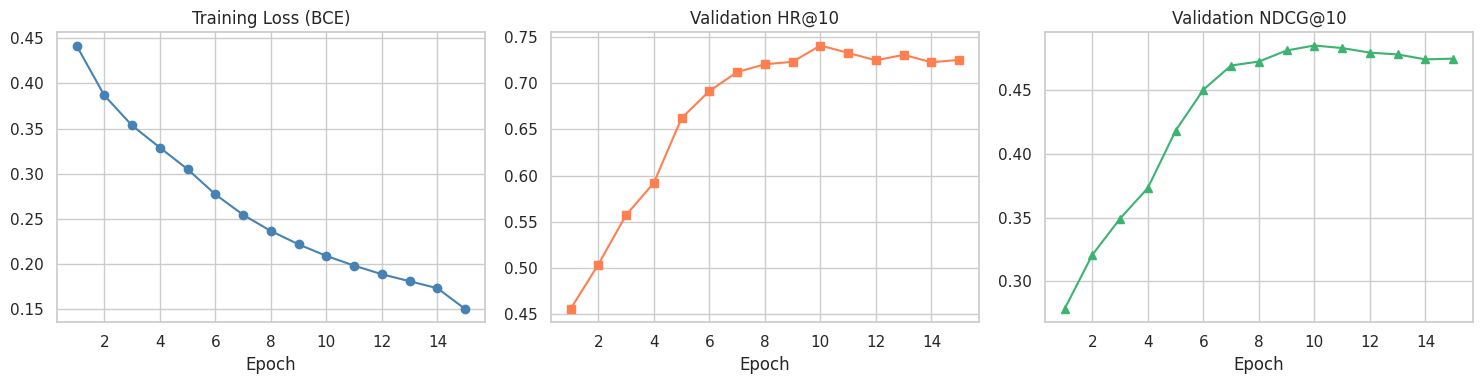

In [ ]:
# ── Training curves ────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
epochs_x = range(1, len(history['loss']) + 1)

axes[0].plot(epochs_x, history['loss'],    marker='o', color='steelblue')
axes[0].set_title('Training Loss (BCE)'); axes[0].set_xlabel('Epoch')

axes[1].plot(epochs_x, history['HR@10'],   marker='s', color='coral')
axes[1].set_title('Validation HR@10');  axes[1].set_xlabel('Epoch')

axes[2].plot(epochs_x, history['NDCG@10'], marker='^', color='mediumseagreen')
axes[2].set_title('Validation NDCG@10'); axes[2].set_xlabel('Epoch')

plt.tight_layout(); plt.show()

## 5 · Test Set Evaluation


📊 Test Set Results
────────────────────────────────────────
  HR@5        : 0.5955
  HR@10       : 0.7289
  HR@20       : 0.8458
  NDCG@5      : 0.4497
  NDCG@10     : 0.4929
  NDCG@20     : 0.5225


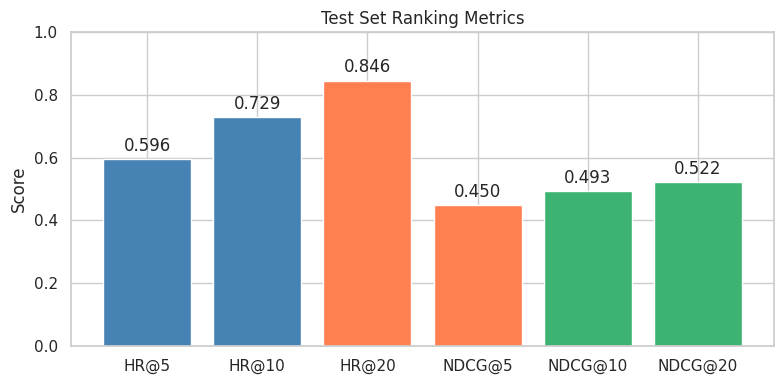

In [ ]:
test_metrics = evaluate(model, test_eval_ds, k_values=[5, 10, 20])

print('\n📊 Test Set Results')
print('─' * 40)
for k, v in test_metrics.items():
    print(f'  {k:<12}: {v:.4f}')


fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(test_metrics.keys(), test_metrics.values(),
              color=['steelblue','steelblue','coral','coral','mediumseagreen','mediumseagreen'])
ax.bar_label(bars, fmt='%.3f', padding=3)
ax.set_title('Test Set Ranking Metrics')
ax.set_ylabel('Score')
ax.set_ylim(0, min(1.0, max(test_metrics.values()) * 1.3))
plt.tight_layout(); plt.show()

## 6 · Making Recommendations

In [ ]:
# ── Recommender API ────────────────────────────────────────────────────────

artist_name = {
    idx: artists[artists['artistID'] == orig_id]['name'].values[0]
    if len(artists[artists['artistID'] == orig_id]) > 0 else f'Artist-{orig_id}'
    for orig_id, idx in item2idx.items()
}
popular_items = train_df['item'].value_counts().index.tolist()
user_history  = train_df.groupby('user')['item'].apply(set).to_dict()


@torch.no_grad()
def recommend_for_user(user_id, top_k=10, exclude_known=True):
    """Get personalised top-K artist recommendations."""
    if user_id not in user2idx:
        print('Unknown user – returning most popular artists.')
        return pd.DataFrame({'rank': range(1, top_k+1),
                             'artist': [artist_name[i] for i in popular_items[:top_k]]})

    u_idx = user2idx[user_id]
    model.eval()
    users  = torch.LongTensor([u_idx] * NUM_ITEMS).to(DEVICE)
    items  = torch.arange(NUM_ITEMS, dtype=torch.long).to(DEVICE)
    scores = model(users, items).cpu().numpy()

    if exclude_known:
        for i in user_history.get(u_idx, set()):
            scores[i] = -np.inf

    top_idx = np.argsort(-scores)[:top_k]
    return pd.DataFrame({
        'rank':   range(1, top_k + 1),
        'artist': [artist_name[i] for i in top_idx],
        'score':  [round(float(scores[i]), 4) for i in top_idx],
    })


@torch.no_grad()
def similar_artists(artist_id, top_k=10):
    """Find similar artists using cosine similarity in embedding space."""
    if artist_id not in item2idx:
        raise ValueError(f'Artist {artist_id} not in training data.')

    model.eval()
    all_ids = torch.arange(NUM_ITEMS, dtype=torch.long).to(DEVICE)
    gmf_emb = model.gmf_item(all_ids)
    mlp_emb = model.mlp_item(all_ids)
    all_emb = torch.cat([gmf_emb, mlp_emb], dim=-1)

    q_idx = item2idx[artist_id]
    query = all_emb[q_idx].unsqueeze(0)
    sims  = F.cosine_similarity(query, all_emb).cpu().numpy()
    sims[q_idx] = -np.inf

    top_idx = np.argsort(-sims)[:top_k]
    return pd.DataFrame({
        'rank':       range(1, top_k + 1),
        'artist':     [artist_name[i] for i in top_idx],
        'similarity': [round(float(sims[i]), 4) for i in top_idx],
    })

In [ ]:


sample_user_id = list(user2idx.keys())[42]
print(f'\n🎧 Top-10 recommendations for User {sample_user_id}:')
recs = recommend_for_user(sample_user_id, top_k=10)
print(recs.to_string(index=False))


u_idx = user2idx[sample_user_id]
hist  = sorted(user_history.get(u_idx, set()))[:10]
print(f'\n📀 User\'s listening history (sample):')
for i, itm in enumerate(hist, 1):
    print(f'  {i:2d}. {artist_name[itm]}')


🎧 Top-10 recommendations for User 45:
 rank               artist  score
    1              Beyoncé 0.9790
    2              Madonna 0.9534
    3 La Oreja de Van Gogh 0.9462
    4          Evanescence 0.9421
    5         Mariah Carey 0.9378
    6       Jennifer Lopez 0.9360
    7        Kylie Minogue 0.9339
    8             Paramore 0.9285
    9      Vanessa Hudgens 0.9261
   10        Justin Bieber 0.9195

📀 User's listening history (sample):
   1. Lady Gaga
   2. Enrique Iglesias
   3. Rihanna
   4. Britney Spears
   5. Kelly Clarkson
   6. Christina Aguilera
   7. Ashlee Simpson
   8. Katy Perry
   9. P!nk
  10. Black Eyed Peas


In [ ]:

top_artist_idx = popular_items[0]
top_artist_orig_id = idx2item[top_artist_idx]
top_artist_name = artist_name[top_artist_idx]

print(f'\n🎸 Artists similar to "{top_artist_name}" (ID={top_artist_orig_id}):')
sim_df = similar_artists(top_artist_orig_id, top_k=10)
print(sim_df.to_string(index=False))


🎸 Artists similar to "Lady Gaga" (ID=89):
 rank             artist  similarity
    1            Beyoncé      0.8705
    2            Rihanna      0.8619
    3      Avril Lavigne      0.8472
    4    Black Eyed Peas      0.8446
    5 Christina Aguilera      0.8357
    6         Katy Perry      0.8310
    7     Britney Spears      0.8297
    8       Mariah Carey      0.8227
    9     Kelly Clarkson      0.8147
   10      Kylie Minogue      0.8052


## 7 · Embedding Visualisation (t-SNE)

Running t-SNE (may take ~1 min)...


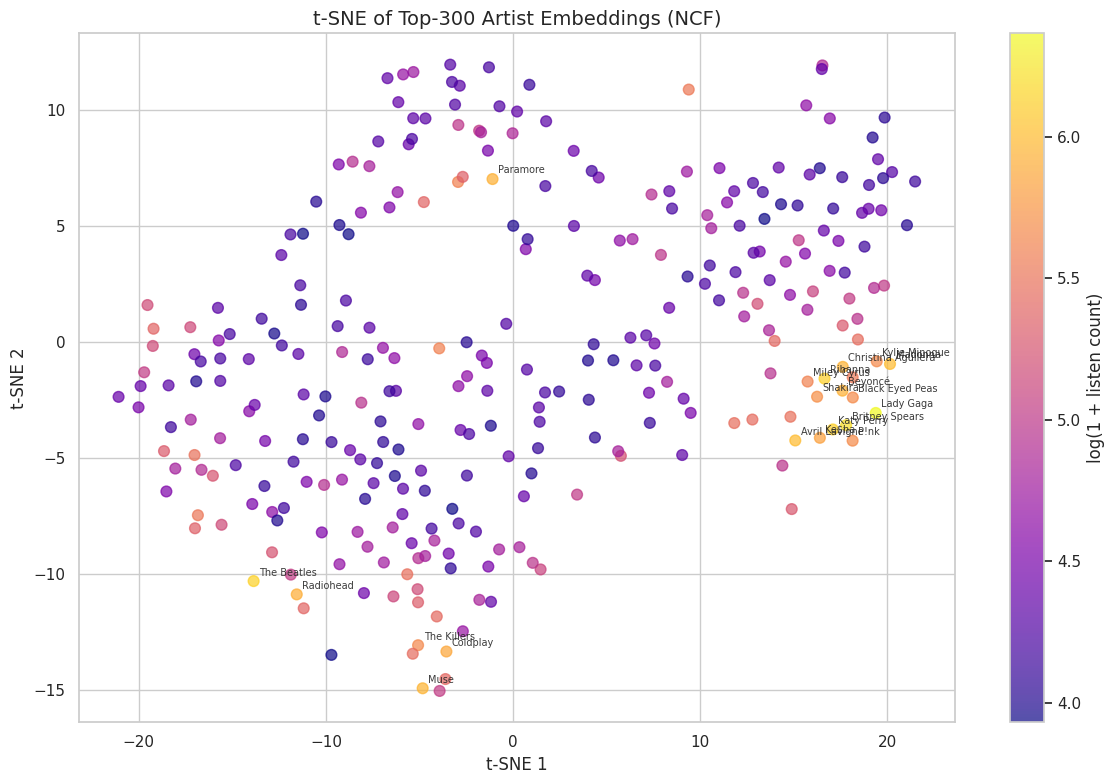

In [ ]:
# ── t-SNE of artist embeddings ─────────────────────────────────────────────


TOP_N = 300
top_items = popular_items[:TOP_N]

model.eval()
with torch.no_grad():
    ids  = torch.LongTensor(top_items).to(DEVICE)
    embs = torch.cat([model.gmf_item(ids), model.mlp_item(ids)], dim=-1).cpu().numpy()

print('Running t-SNE (may take ~1 min)...')
tsne = TSNE(n_components=2, perplexity=30, n_iter=1000, random_state=42)
coords = tsne.fit_transform(embs)

# Colour by listen count (popularity)
listen_counts = [train_df[train_df['item'] == i]['item'].count() for i in top_items]

fig, ax = plt.subplots(figsize=(12, 8))
sc = ax.scatter(coords[:, 0], coords[:, 1],
                c=np.log1p(listen_counts), cmap='plasma', alpha=0.7, s=60)
plt.colorbar(sc, label='log(1 + listen count)')

# Label the 20 most popular
for idx_pos, i in enumerate(top_items[:20]):
    ax.annotate(artist_name[i], coords[idx_pos],
                fontsize=7, alpha=0.9,
                xytext=(4, 4), textcoords='offset points')

ax.set_title(f't-SNE of Top-{TOP_N} Artist Embeddings (NCF)', fontsize=14)
ax.set_xlabel('t-SNE 1'); ax.set_ylabel('t-SNE 2')
plt.tight_layout(); plt.show()

## 8 · Model Comparison (GMF vs MLP vs NCF)

In [ ]:
# ── GMF model ─────────────────────────────────────────────────────────────
class GMF(nn.Module):
    def __init__(self, num_users, num_items, embed_dim=64):
        super().__init__()
        self.user_emb = nn.Embedding(num_users, embed_dim)
        self.item_emb = nn.Embedding(num_items, embed_dim)
        self.out      = nn.Linear(embed_dim, 1, bias=False)
        nn.init.normal_(self.user_emb.weight, std=0.01)
        nn.init.normal_(self.item_emb.weight, std=0.01)
    def forward(self, u, i):
        return torch.sigmoid(self.out(self.user_emb(u) * self.item_emb(i))).squeeze(-1)

# ── MLP-only model ────────────────────────────────────────────────────────
class MLPRec(nn.Module):
    def __init__(self, num_users, num_items, embed_dim=32, layers=None):
        super().__init__()
        if layers is None: layers = [128, 64, 32]
        self.user_emb = nn.Embedding(num_users, embed_dim)
        self.item_emb = nn.Embedding(num_items, embed_dim)
        self.mlp, last = build_mlp(embed_dim * 2, layers)
        self.out = nn.Linear(last, 1)
    def forward(self, u, i):
        x = torch.cat([self.user_emb(u), self.item_emb(i)], dim=-1)
        return torch.sigmoid(self.out(self.mlp(x))).squeeze(-1)

def quick_train(m, epochs=10):
    m = m.to(DEVICE)
    opt = torch.optim.Adam(m.parameters(), lr=1e-3, weight_decay=1e-5)
    crit = nn.BCELoss()
    m.train()
    for ep in range(epochs):
        for u, i, l in train_loader:
            u, i, l = u.to(DEVICE), i.to(DEVICE), l.to(DEVICE)
            opt.zero_grad()
            crit(m(u, i), l).backward()
            opt.step()
    return evaluate(m, val_eval_ds, k_values=[10])

print('Training GMF (10 epochs)...')
gmf_metrics = quick_train(GMF(NUM_USERS, NUM_ITEMS, embed_dim=64))
print('GMF:', gmf_metrics)

print('\nTraining MLP (10 epochs)...')
mlp_metrics = quick_train(MLPRec(NUM_USERS, NUM_ITEMS))
print('MLP:', mlp_metrics)

print('\nNCF (already trained):')
ncf_metrics = evaluate(model, val_eval_ds, k_values=[10])
print('NCF:', ncf_metrics)

Training GMF (10 epochs)...
GMF: {'HR@10': 0.4604, 'NDCG@10': 0.2855}

Training MLP (10 epochs)...
MLP: {'HR@10': 0.5364, 'NDCG@10': 0.3367}

NCF (already trained):
NCF: {'HR@10': 0.7406, 'NDCG@10': 0.4851}


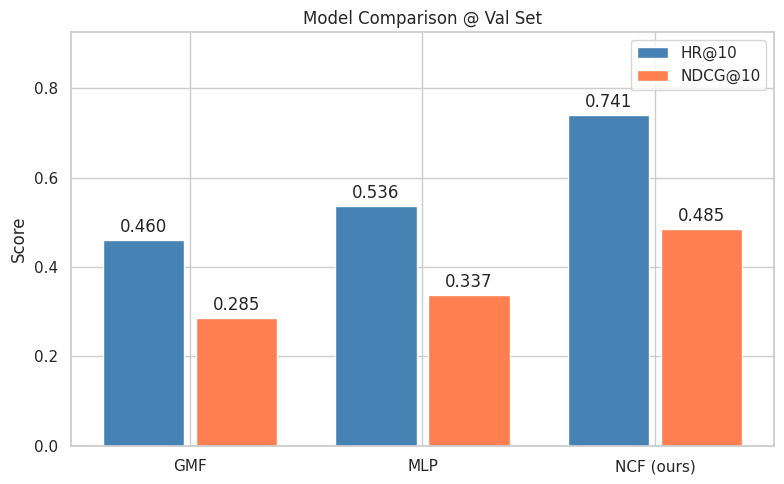

In [ ]:
# ── Comparison bar chart ──────────────────────────────────────────────────
models = ['GMF', 'MLP', 'NCF (ours)']
hr10   = [gmf_metrics['HR@10'], mlp_metrics['HR@10'], ncf_metrics['HR@10']]
ndcg10 = [gmf_metrics['NDCG@10'], mlp_metrics['NDCG@10'], ncf_metrics['NDCG@10']]

x = np.arange(len(models))
fig, ax = plt.subplots(figsize=(8, 5))
b1 = ax.bar(x - 0.2, hr10,   0.35, label='HR@10',   color='steelblue')
b2 = ax.bar(x + 0.2, ndcg10, 0.35, label='NDCG@10', color='coral')
ax.bar_label(b1, fmt='%.3f', padding=3)
ax.bar_label(b2, fmt='%.3f', padding=3)
ax.set_xticks(x); ax.set_xticklabels(models)
ax.set_ylabel('Score'); ax.set_title('Model Comparison @ Val Set')
ax.legend(); ax.set_ylim(0, max(hr10 + ndcg10) * 1.25)
plt.tight_layout(); plt.show()

## 9 · Save & Load the Model

In [ ]:
# ── Save ──────────────────────────────────────────────────────────────────
os.makedirs('checkpoints', exist_ok=True)
torch.save({
    'model_state': model.state_dict(),
    'user2idx':    user2idx,
    'item2idx':    item2idx,
    'num_users':   NUM_USERS,
    'num_items':   NUM_ITEMS,
    'metrics':     test_metrics,
}, 'checkpoints/ncf_music_rec.pt')
print('Model saved to checkpoints/ncf_music_rec.pt')

# ── Load ──────────────────────────────────────────────────────────────────
ckpt = torch.load('checkpoints/ncf_music_rec.pt', map_location=DEVICE, weights_only=False)
loaded_model = NCF(ckpt['num_users'], ckpt['num_items']).to(DEVICE)
loaded_model.load_state_dict(ckpt['model_state'])
loaded_model.eval()
print('Model loaded successfully. Test metrics:', ckpt['metrics'])

Model saved to checkpoints/ncf_music_rec.pt
Model loaded successfully. Test metrics: {'HR@5': 0.5955, 'HR@10': 0.7289, 'HR@20': 0.8458, 'NDCG@5': 0.4497, 'NDCG@10': 0.4929, 'NDCG@20': 0.5225}
